In [ ]:
# updates in v4_01:
# we'll drop all alternate overlap strategies. we'll require no minimum overlap
# we're going to run this version with the 0.01 p value threshold and compare to a forked notebook at the 0.05 threshold for final (does that mean final?) decision

In [1]:
# import packages #
import pandas as pd
import os
import matplotlib
import matplotlib.pyplot as mpl
import seaborn as sns
from scipy import stats
from tqdm import tqdm
import numpy as np
from collections import Counter
import matplotlib.colors as mcolors
from tangermeme.io import read_meme
import torch
from tqdm import tqdm
import pybedtools
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import Table2x2

In [2]:
# open enhancer level averaged predictions #
all_mean_preds = pd.read_csv('../processed_data/all_dELS_sat_mut_groupby_mean_v2.tsv',
                             sep = '\t')

In [3]:
# open cell type specific cCRE calls #
# K562 #
k562_cCREs = pd.read_csv('../raw_data/ENCFF414OGC_ENCFF806YEZ_ENCFF849TDM_ENCFF736UDR_K562_cCRE.bed',
                        sep = '\t',
                        header = None)
# HepG2 #
hepg2_cCREs = pd.read_csv('../raw_data/ENCFF546MZK_ENCFF732PJK_ENCFF795ONN_ENCFF357NFO_HepG2_cCRE.bed',
                          sep = '\t',
                          header = None)
# SKNSH #
sknsh_cCREs = pd.read_csv('../raw_data/ENCFF280RMA_ENCFF651WOM_ENCFF262UEH_ENCFF850MLW_SKNSH_cCRE.bed',
                          sep = '\t',
                          header = None)

In [4]:
# define path to bed files as a variable
path2beds = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/annotated_seqlets/bed_files'

In [5]:
# define a function for adding cell type specific cCRE status to dataframe #
def add_cell_cCRE (ann_df,
                  k_cCRE_df,
                  h_cCRE_df,
                  s_cCRE_df):
    copy_df = ann_df.copy()
    # make dictionaries of enhancer id and cell type annotation #
    # k562 #
    k_dict = dict(zip(k_cCRE_df[3],
                      k_cCRE_df[9]))
    # hepg2 #
    h_dict = dict(zip(h_cCRE_df[3],
                      h_cCRE_df[9]))
    # sknsh #
    s_dict = dict(zip(s_cCRE_df[3],
                      s_cCRE_df[9]))
    # add k562 annotation to df
    copy_df.loc[:,'k562_cCRE_ann'] = [k_dict.get(i) for i in tqdm(copy_df['id'])]
    # add hepg2 annotation to df #
    copy_df.loc[:,'hepg2_cCRE_ann'] = [h_dict.get(i) for i in tqdm(copy_df['id'])]
    # add sknsh annotation to df #
    copy_df.loc[:,'sknsh_cCRE_ann'] = [s_dict.get(i) for i in tqdm(copy_df['id'])]
    return copy_df

In [6]:
# add cCRE status to averaged predictions #
cCRE_ann_mean_preds = add_cell_cCRE(all_mean_preds, k562_cCREs, hepg2_cCREs, sknsh_cCREs)

100%|██████████| 1432012/1432012 [00:00<00:00, 1802300.28it/s]


In [7]:
# open CRISPR links data
crispr_gene_links = pd.read_csv('../raw_data/V4-hg38.Gene-Links.CRISPR.txt', sep = '\t', header = None)
# filter for K562
k562_crispr_links = crispr_gene_links[(crispr_gene_links[7] == 'K562') & (crispr_gene_links[9] < 0.05)]
# make a dictionary for annotating predictions
k562_crispri_link_dict = dict(zip(k562_crispr_links[0], [1 for i in range(len(k562_crispr_links))]))
# k562 CRISPRi link 
cCRE_ann_mean_preds.loc[:, 'k562_crispri_link'] = [1 if i in k562_crispri_link_dict.keys() else '.' for i in cCRE_ann_mean_preds['id']]

In [8]:
# define function to plot average activity of dELS vs. non cell dELS #
def dELS_vs_low_DNase_box (enhancer_preds, random_seq_preds, outpath):
    # define palette based on cell type #
    # K562 #
    k_pal = {'Low-DNase' : 'gray',
             'dELS' : '#00A79D',
             'K562 CRISPRi Linked' : '#0054A7',
             'Non-cCRE' : 'aliceblue'}
    # HepG2 #
    h_pal = {'dELS' : '#FBB040',
             'Low-DNase' : 'gray',
             'Non-cCRE' : 'aliceblue'}
    # SKNSH #
    s_pal = {'dELS' : '#ED1C24',
             'Low-DNase' : 'gray',
             'Non-cCRE' : 'aliceblue'}
    # make lists for assigning categorical to each set
    kCat = ['Non-cCRE', 'Low-DNase', 'dELS', 'K562 CRISPRi Linked']
    hCat = ['Non-cCRE', 'Low-DNase', 'dELS']
    sCat = ['Non-cCRE', 'Low-DNase', 'dELS']
    # Reformat DFs
    # K562
    k_enhancer_preds = enhancer_preds[enhancer_preds['k562_cCRE_ann'].isin(['dELS', 'Low-DNase'])].copy()#.sort_values(by='k562_cCRE_ann', ascending=False)
    k_enhancer_preds.loc[:,'annotation'] = k_enhancer_preds['k562_cCRE_ann']
    # add K562 CRISPRi linked enhancers
    kCRISPRi_linked = enhancer_preds[enhancer_preds['k562_crispri_link'] == 1].copy()
    kCRISPRi_linked.loc[:, 'annotation'] = ['K562 CRISPRi Linked' for i in range(len(kCRISPRi_linked))]
    k2plot = pd.concat([
        k_enhancer_preds.filter(['k562_ref_pred', 'annotation']),
        kCRISPRi_linked.filter(['k562_ref_pred', 'annotation']),
        random_sequence_preds.filter(['k562_ref_pred', 'annotation'])
    ])
    # assign categorical to annotation
    k2plot['annotation'] = pd.Categorical(k2plot['annotation'], categories=kCat)
    k2plot = k2plot.sort_values(by='annotation')
    # HepG2
    h_enhancer_preds = enhancer_preds[enhancer_preds['hepg2_cCRE_ann'].isin(['dELS', 'Low-DNase'])].sort_values(by='hepg2_cCRE_ann', ascending=False)
    h_enhancer_preds.loc[:,'annotation'] = h_enhancer_preds['hepg2_cCRE_ann']
    h2plot = pd.concat([
        h_enhancer_preds.filter(['hepg2_ref_pred', 'annotation']),
        random_sequence_preds.filter(['hepg2_ref_pred', 'annotation'])
    ])
    # assign categorical to annotation
    h2plot['annotation'] = pd.Categorical(h2plot['annotation'], categories=hCat)
    h2plot = h2plot.sort_values(by='annotation')
    # SKNSH
    s_enhancer_preds = enhancer_preds[enhancer_preds['sknsh_cCRE_ann'].isin(['dELS', 'Low-DNase'])].sort_values(by='sknsh_cCRE_ann', ascending=False)
    s_enhancer_preds.loc[:,'annotation'] = s_enhancer_preds['sknsh_cCRE_ann']
    s2plot = pd.concat([
        s_enhancer_preds.filter(['sknsh_ref_pred', 'annotation']),
        random_sequence_preds.filter(['sknsh_ref_pred', 'annotation'])
    ])
    s2plot['annotation'] = pd.Categorical(s2plot['annotation'], categories=sCat)
    s2plot = s2plot.sort_values(by='annotation')
    # define function for running ANOVAs
    def anova_test (plotdf, cell_type):
        # split into groups
        # dELS
        dELS = plotdf[plotdf['annotation'] == 'dELS'][f'{cell_type}_ref_pred']
        # dnase
        LowDNase = plotdf[plotdf['annotation'] == 'Low-DNase'][f'{cell_type}_ref_pred']
        # non-ccre
        nonCRE = plotdf[plotdf['annotation'] == 'Non-cCRE'][f'{cell_type}_ref_pred']
        # perform ANOVA and return f_stat and pvalue
        f_stat, p_value = stats.f_oneway(dELS, LowDNase, nonCRE)
        return f_stat, p_value, [dELS, LowDNase, nonCRE];
    # define additional function for anova in K562
    def anova_testK562 (plotdf, cell_type):
        # split into groups
        # dELS
        dELS = plotdf[plotdf['annotation'] == 'dELS'][f'{cell_type}_ref_pred']
        # dnase
        LowDNase = plotdf[plotdf['annotation'] == 'Low-DNase'][f'{cell_type}_ref_pred']
        # non-ccre
        nonCRE = plotdf[plotdf['annotation'] == 'Non-cCRE'][f'{cell_type}_ref_pred']
        # K562 crispri linked
        CRISPRi_linked = plotdf[plotdf['annotation'] == 'K562 CRISPRi Linked'][f'{cell_type}_ref_pred']
        # perform ANOVA and return f_stat and pvalue
        f_stat, p_value = stats.f_oneway(dELS, LowDNase, nonCRE, CRISPRi_linked)
        return f_stat, p_value, [dELS, LowDNase, nonCRE, CRISPRi_linked]
    # perform ANOVA for K562
    k_fStat, k_pVal, kGroups = anova_testK562(k2plot, 'k562')
    print('K562 ANOVA')
    print(f"F-statistic K562: {k_fStat}")
    print(f"P-value K562: {k_pVal}")
    # perform ANOVA for HepG2
    h_fStat, h_pVal, hGroups = anova_test(h2plot, 'hepg2')
    print('HepG2 ANOVA')
    print(f"F-statistic HepG2: {h_fStat}")
    print(f"P-value HepG2: {h_pVal}")
    # perform ANOVA for SKNSH
    s_fStat, s_pVal, sGroups = anova_test(s2plot, 'sknsh')
    print('SKNSH ANOVA')
    print(f"F-statistic SKNSH: {s_fStat}")
    print(f"P-value SKNSH: {s_pVal}")    
    # define function for performing tests for each cell type
    def performTtests (groupList, cell_type):
        # make a list of comparisons
        comps = [
            ('dELS', 'Low-DNase', stats.ttest_ind(groupList[0], groupList[1])), # dELS vs. Low-DNase
            ('dELS', 'Non-cCRE', stats.ttest_ind(groupList[0], groupList[-1])), # dELS vs. Non-cCRE
            ('Low-DNase', 'Non-cCRE', stats.ttest_ind(groupList[1], groupList[-1])), # Low-DNase vs. Non-cCRE
        ]
        # get p-values
        p_values = [comp[2].pvalue for comp in comps]
        # do benjamini-hochberg correction
        reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')
        # make annotation dictionary
        dict4annotation = {
            'dELS_LowDNase' : {
                'raw_p' : comps[0][2].pvalue,
                'adj_p' : p_adjusted[0],
                't_stat' : comps[0][2].statistic
            },
            'dELS_nonCRE' : {
                'raw_p' : comps[1][2].pvalue,
                'adj_p' : p_adjusted[1],
                't_stat' : comps[1][2].statistic
            },
            'LowDNase_nonCRE' : {
                'raw_p' : comps[2][2].pvalue,
                'adj_p' : p_adjusted[2],
                't_stat' : comps[2][2].statistic
            }
        }
        return dict4annotation
    # define function for performing tests for each cell type - K562 w/ CRISPRi link
    def performTtests_K562 (groupList, cell_type):
        # make a list of comparisons [dELS, LowDNase, nonCRE, CRISPRi_linked]
        comps = [
            ('dELS', 'Low-DNase', stats.ttest_ind(groupList[0], groupList[1])), # dELS vs. Low-DNase
            ('dELS', 'Non-cCRE', stats.ttest_ind(groupList[0], groupList[2])), # dELS vs. Non-cCRE
            ('Low-DNase', 'Non-cCRE', stats.ttest_ind(groupList[1], groupList[2])), # Low-DNase vs. Non-cCRE
            ('Non-cCRE', 'K562 CRISPRi Linked', stats.ttest_ind(groupList[2], groupList[-1])), # Non-cCRE vs. K562 CRISPRi Linked
            ('Low-DNase', 'K562 CRISPRi Linked', stats.ttest_ind(groupList[1], groupList[-1])), # Low-DNase vs. K562 CRISPRi Linked
            ('dELS', 'K562 CRISPRi Linked', stats.ttest_ind(groupList[0], groupList[-1])) # dELS vs. CRISPRi Linked
        ]
        # get p-values
        p_values = [comp[2].pvalue for comp in comps]
        # do benjamini-hochberg correction
        reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')
        # make annotation dictionary
        dict4annotation = {
            'dELS_LowDNase' : {
                'raw_p' : comps[0][2].pvalue,
                'adj_p' : p_adjusted[0],
                't_stat' : comps[0][2].statistic
            },
            'dELS_nonCRE' : {
                'raw_p' : comps[1][2].pvalue,
                'adj_p' : p_adjusted[1],
                't_stat' : comps[1][2].statistic
            },
            'LowDNase_nonCRE' : {
                'raw_p' : comps[2][2].pvalue,
                'adj_p' : p_adjusted[2],
                't_stat' : comps[2][2].statistic
            },
            'nonCRE_CRISPRi' : {
                'raw_p' : comps[3][2].pvalue,
                'adj_p' : p_adjusted[3],
                't_stat' : comps[3][2].statistic
            },
            'LowDNase_CRISPRi' : {
                'raw_p' : comps[4][2].pvalue,
                'adj_p' : p_adjusted[4],
                't_stat' : comps[4][2].statistic
            },
            'dELS_CRISPRi' : {
                'raw_p' : comps[5][2].pvalue,
                'adj_p' : p_adjusted[5],
                't_stat' : comps[5][2].statistic
            }
        }
        return dict4annotation
    # perform multiple t-tests with correction
    # K562
    k_testDict = performTtests_K562(kGroups, 'k562')
    # HepG2
    h_testDict = performTtests(hGroups, 'hepg2')
    # SKNSH
    s_testDict = performTtests(sGroups, 'sknsh')

    # get maximum predictions for each plot for annotation purposes
    kMax = k2plot['k562_ref_pred'].max()
    hMax = h2plot['hepg2_ref_pred'].max()
    sMax = s2plot['sknsh_ref_pred'].max()

    # plot mean reference activity for called cCREs vs. Low-DNase regions #
    f = mpl.figure(figsize = (4,3), dpi = 300)
    gs = f.add_gridspec(1,3)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    # plot k562 #
    with sns.axes_style('ticks'):
        ax02 = f.add_subplot(gs[0,2])
        ax02.set_box_aspect(1)
        sns.violinplot(data=k2plot,
                    x='annotation',
                    y='k562_ref_pred',
                    hue='annotation',
                    linewidth=0.5,
                    palette=k_pal)
        # add 'activity' line
        ax02.hlines(y=1, xmin= -0.5, xmax=3.5, linestyle='dashed', alpha=0.25, linewidth=0.75, color='k')
        # add line for comparison between non-cCRE and Low-DNase
        ax02.hlines(y=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.05, xmin=0.0, xmax=1.0, linewidth=0.5, color='k')
        ax02.vlines(x=[0, 1], ymin=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.03, ymax=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.07, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=0.5, 
                 y=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.075, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # add line for comparison between non-cCRE and dELS
        ax02.hlines(y=kMax * 1.05, xmin=0, xmax=2, linewidth=0.5, color='k')
        ax02.vlines(x=[0,2], ymin=kMax * 1.03, ymax=kMax*1.07, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=1, 
                 y=kMax * 1.075, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # add line for comparison between non-cCRE and CRISPRi
        ax02.hlines(y=kMax * 1.25, xmin=0, xmax=3, linewidth=0.5, color='k')
        ax02.vlines(x=[0,3], ymin=kMax * 1.23, ymax=kMax *1.27, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=1.5, 
                 y=kMax * 1.275, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
         # add line for comparison between Low-DNase and dELS
        ax02.hlines(y=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.15, xmin=1.0, xmax=2.0, linewidth=0.5, color='k')
        ax02.vlines(x=1, ymin=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.13, ymax=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.17, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=1.5, 
                 y=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.175, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # add line for comparison between Low-DNase and CRSIPRi
        ax02.hlines(y=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.25, xmin=1.0, xmax=3.0, linewidth=0.5, color='k')
        ax02.vlines(x=[1,3], ymin=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.23, ymax=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.27, linewidth=0.5, color='k')
        # add line for comparison between dELS and CRISPRi
        ax02.hlines(y=kMax * 1.15, xmin=2, xmax=3, linewidth=0.5, color='k')
        ax02.vlines(x=[2,3], ymin=kMax * 1.13, ymax=kMax *1.17, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=2.5, 
                 y=kMax * 1.175, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=2.5, 
                 y=np.max(k2plot[k2plot['annotation'] == 'Low-DNase']['k562_ref_pred']) * 1.275, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        ax02.set_yticks([0, 5, 10, 15], [0, 5, 10, 15], fontsize=4)
        ax02.set_xticks([0,1,2,3], ['Non-cCRE', 'K562 Low-DNase', 'K562 dELS', 'K562 CRISPRi Linked'], fontsize = 4, rotation=90)
        mpl.ylabel('K562 Mean Activity', fontsize = 4)
        mpl.xlabel('')
    # plot hepg2 #
    with sns.axes_style('ticks'):
        ax01 = f.add_subplot(gs[0,0], sharey=ax02)
        ax01.set_box_aspect(1)
        sns.violinplot(data=h2plot,
                    x='annotation',
                    y='hepg2_ref_pred',
                    hue='annotation',
                    linewidth=0.5,
                    palette=h_pal)
        # add 'activity' line
        mpl.hlines(y=1, xmin= -0.5, xmax=2.5, linestyle='dashed', alpha=0.25, linewidth=0.75, color='k')
        # add line for comparison between dELS and Low-DNase
        ax01.hlines(y=hMax * 1.05, xmin=0.0, xmax=1.0, linewidth=0.5, color='k')
        ax01.vlines(x=[0, 1], ymin=hMax * 1.03, ymax=hMax * 1.07, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=0.5, 
                 y=hMax * 1.075, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # add line for comparison between dELS and non-CRE
        ax01.hlines(y=hMax * 1.15, xmin=0.0, xmax=2.0, linewidth=0.5, color='k', capstyle='projecting')
        ax01.vlines(x=[0, 2], ymin=hMax * 1.13, ymax=hMax * 1.17, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=1, 
                 y=hMax * 1.175, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # add line for comparison between Low-DNase and non-CRE
        ax01.hlines(y=hMax * 1.25, xmin=1.0, xmax=2.0, linewidth=0.5, color='k', capstyle='projecting')
        ax01.vlines(x=[1, 2], ymin=hMax * 1.23, ymax=hMax * 1.27, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=1.5, 
                 y=hMax * 1.275, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        ax01.set_xticks([0,1,2], ['Non-cCRE', 'HepG2 Low-DNase', 'HepG2 dELS'], fontsize = 4)
        ax01.set_yticks([0, 5, 10, 15], [0, 5, 10, 15], fontsize=4)
        mpl.xticks(fontsize = 4, rotation=90)
        mpl.xlabel('')
        mpl.ylabel('HepG2 Mean Activity', fontsize = 4)
    # plot sknsh #
    with sns.axes_style('ticks'):
        ax03 = f.add_subplot(gs[0,1], sharey=ax02)
        ax03.set_box_aspect(1)
        sns.violinplot(data=s2plot,
                    x='annotation',
                    y='sknsh_ref_pred',
                    hue='annotation',
                    linewidth=0.5,
                    palette=s_pal)
        # add 'activity' line
        ax03.hlines(y=1, xmin= -0.5, xmax=2.5, linestyle='dashed', alpha=0.25, linewidth=0.75, color='k')
        # add line for comparison between dELS and Low-DNase
        ax03.hlines(y=sMax * 1.05, xmin=0.0, xmax=1.0, linewidth=0.5, color='k')
        ax03.vlines(x=[0,1], ymin=sMax*1.03, ymax=sMax*1.07, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=0.5, 
                 y=sMax * 1.075, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # add line for comparison between dELS and non-CRE
        ax03.hlines(y=sMax * 1.15, xmin=0.0, xmax=2.0, linewidth=0.5, color='k')
        ax03.vlines(x=[0,2], ymin=sMax*1.13, ymax=sMax*1.17, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=1.0, 
                 y=sMax * 1.175, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        # add line for comparison between Low-DNase and non-CRE
        ax03.hlines(y=sMax * 1.25, xmin=1.0, xmax=2.0, linewidth=0.5, color='k')
        ax03.vlines(x=[1,2], ymin=sMax*1.23, ymax=sMax*1.27, linewidth=0.5, color='k')
        # annotate the pvalue from the t-test for that comparison
        mpl.text(x=1.5, 
                 y=sMax * 1.275, 
                 s='***', 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 fontsize=3)
        ax03.set_xticks([0,1,2], ['Non-cCRE', 'SK-N-SH Low-DNase', 'SK-N-SH dELS'], fontsize = 4)
        mpl.xticks(fontsize = 4, rotation=90)
        mpl.xlabel('')
        mpl.ylabel('SK-N-SH Mean Activity', fontsize=4)
        ax03.set_yticks([0,5,10,15], [0,5,10,15], fontsize=4)
    sns.despine(left=False, bottom=False)
    mpl.tight_layout()
    #mpl.savefig(outpath)
    return k_testDict, h_testDict, s_testDict;

In [9]:
# open random sequence predictions
# define function to reformat predictions #
def vcf2df (pred_df):
    # make lists of preds for new column
    # k562
    k_ref = []
    k_alt = []
    k_skew = []
    # hepg2
    h_ref = []
    h_alt = []
    h_skew = []
    # sknsh
    s_ref = []
    s_alt = []
    s_skew = []
    # parse predictions in 'INFO' column
    for i in tqdm(pred_df['INFO']):
        all_preds = i.split(';')
        # k562
        k_ref.append(float(all_preds[0].split('=')[-1]))
        k_alt.append(float(all_preds[3].split('=')[-1]))
        k_skew.append(float(all_preds[6].split('=')[-1]))
        # hepg2
        h_ref.append(float(all_preds[1].split('=')[-1]))
        h_alt.append(float(all_preds[4].split('=')[-1]))
        h_skew.append(float(all_preds[7].split('=')[-1]))
        # sknsh
        s_ref.append(float(all_preds[2].split('=')[-1]))
        s_alt.append(float(all_preds[5].split('=')[-1]))
        s_skew.append(float(all_preds[8].split('=')[-1]))
    
    df = pd.DataFrame({'chrom' : pred_df['chrom'],
                       'pos' : pred_df['pos'],
                       'id' : pred_df['id'],
                       'ref' : pred_df['ref'],
                       'alt' : pred_df['alt'],
                       'k562_ref_pred' : k_ref,
                       'k562_alt_pred' : k_alt,
                       'k562_skew_pred' : k_skew,
                       'hepg2_ref_pred' : h_ref,
                       'hepg2_alt_pred' : h_alt,
                       'hepg2_skew_pred' : h_skew,
                       'sknsh_ref_pred' : s_ref,
                       'sknsh_alt_pred' : s_alt,
                       'sknsh_skew_pred' : s_skew})
    return df
# iterate through all predictions and concatenate #
random_sequence_preds = pd.concat([vcf2df(pd.read_csv(f'../mpac_preds/random_interval_preds/{i}', sep = '\t')) for i in tqdm([i for i in os.listdir('../mpac_preds/random_interval_preds/') if i.endswith('.vcf')])])

  0%|          | 0/22 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:14<00:00,  1.52it/s]


In [10]:
# add annotation to random sequence DFs
random_sequence_preds.loc[:, 'annotation'] = ['Non-cCRE' for i in range(len(random_sequence_preds))]

K562 ANOVA
F-statistic K562: 65153.45319843639
P-value K562: 0.0
HepG2 ANOVA
F-statistic HepG2: 104173.8059633749
P-value HepG2: 0.0
SKNSH ANOVA
F-statistic SKNSH: 48978.80472035506
P-value SKNSH: 0.0


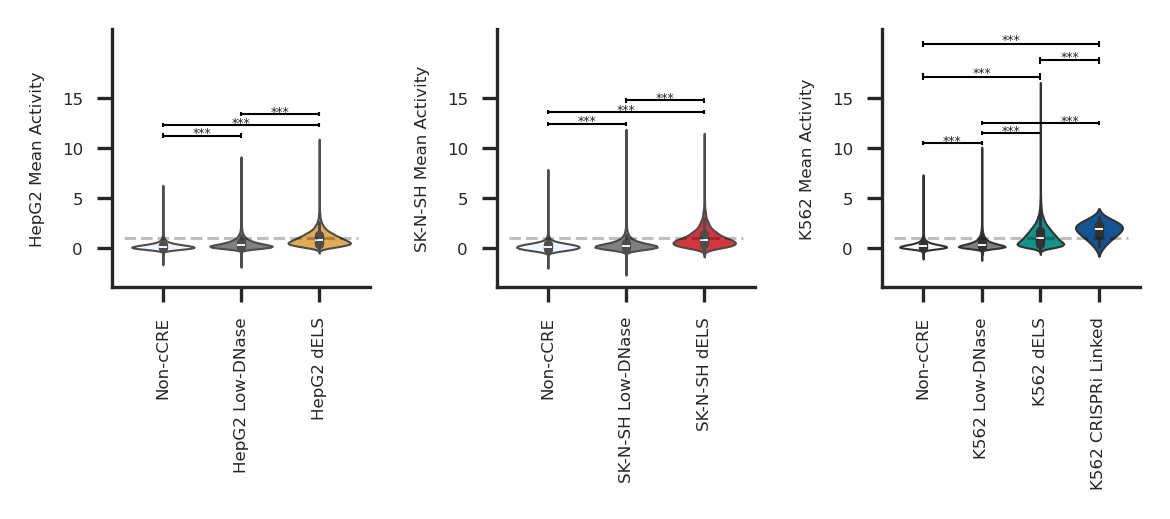

In [11]:
k_tTests, h_tTests, s_tTests = dELS_vs_low_DNase_box(cCRE_ann_mean_preds, 
                                                     random_sequence_preds,
                                                     '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/figures/mean_ref_activity_violin_with_nonCRE_v4.pdf')

In [12]:
k_tTests

{'dELS_LowDNase': {'raw_p': np.float64(0.0),
  'adj_p': np.float64(0.0),
  't_stat': np.float64(284.8577840099219)},
 'dELS_nonCRE': {'raw_p': np.float64(0.0),
  'adj_p': np.float64(0.0),
  't_stat': np.float64(426.2678965643032)},
 'LowDNase_nonCRE': {'raw_p': np.float64(0.0),
  'adj_p': np.float64(0.0),
  't_stat': np.float64(280.8621208078401)},
 'nonCRE_CRISPRi': {'raw_p': np.float64(1.2316245914994694e-79),
  'adj_p': np.float64(1.8474368872492042e-79),
  't_stat': np.float64(-18.89763652254134)},
 'LowDNase_CRISPRi': {'raw_p': np.float64(1.3113303780418611e-37),
  'adj_p': np.float64(1.5735964536502332e-37),
  't_stat': np.float64(-12.817726839226209)},
 'dELS_CRISPRi': {'raw_p': np.float64(0.008138012483803662),
  'adj_p': np.float64(0.008138012483803662),
  't_stat': np.float64(-2.6464432481391413)}}

In [12]:
# get the number of cCRE category
# k562
display(cCRE_ann_mean_preds['k562_cCRE_ann'].value_counts())
# hepg2
display(cCRE_ann_mean_preds['hepg2_cCRE_ann'].value_counts())
# sknsh
display(cCRE_ann_mean_preds['sknsh_cCRE_ann'].value_counts())

k562_cCRE_ann
Low-DNase     1346605
dELS            34430
CA-TF           28049
CA-CTCF         18798
CA-only          2144
CA-H3K4me3       1986
Name: count, dtype: int64

hepg2_cCRE_ann
Low-DNase     1364979
dELS            28645
CA-TF           18545
CA-CTCF         14746
CA-H3K4me3       4311
CA-only           786
Name: count, dtype: int64

sknsh_cCRE_ann
Low-DNase     1369054
CA-only         19032
CA-TF           14296
CA-CTCF         13211
dELS            10330
CA-H3K4me3       6089
Name: count, dtype: int64

In [13]:
cCRE_ann_mean_preds['k562_crispri_link'].value_counts()

k562_crispri_link
.    1431991
1         21
Name: count, dtype: int64

In [11]:
# look into how seqlets are overlapping in enhancers
# open merged seqlet BED files
os.chdir('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/annotated_seqlets/bed_files/')

# open each bed file and add n seqlets per interval
# no minimum overlap
# k562
k_noMin_merge = pd.read_csv('all_K562_bedOps_merged_noMin_seqlets_0.01.bed', sep = '\t', header = None)
k_noMin_merge[4] = [len(i.split(';')) for i in k_noMin_merge[3]]
# hepg2
h_noMin_merge = pd.read_csv('all_HepG2_bedOps_merged_noMin_seqlets_0.01.bed', sep = '\t', header = None)
h_noMin_merge[4] = [len(i.split(';')) for i in h_noMin_merge[3]]
# sknsh
s_noMin_merge = pd.read_csv('all_SKNSH_bedOps_merged_noMin_seqlets_0.01.bed', sep = '\t', header = None)
s_noMin_merge[4] = [len(i.split(';')) for i in s_noMin_merge[3]]

In [12]:
def assign_representative_tf(bed_file):
    """
    Reads a mapped BED file, assigns a single representative TF, and
    classifies its activity based on attribution score.

    Args:
        bed_file (pd.DataFrame): DataFrame from the bedmap output.

    Returns:
        pd.DataFrame: The original DataFrame with two new columns:
                      'representative_tf' and 'activity_class'.
    """
    df = bed_file
    data_column_index = 3

    representative_tfs = []
    activity_classes = [] # New list to store the activity class

    for index, row in tqdm(df.iterrows()):
        mapped_info_string = str(row[data_column_index])
        tf_hits = mapped_info_string.split(';')
        
        best_tf = ''
        best_score = 0.0 # Variable to hold the signed score of the winner
        
        if len(tf_hits) == 1:
            # RULE 1: Only one TF is present
            parts = tf_hits[0].split('_')
            best_tf = parts[0]
            try:
                best_score = float(parts[-1])
            except (ValueError, IndexError):
                best_score = 0.0 # Default if score is missing
        else:
            # RULES 2 & 3: Multiple TFs are present
            max_abs_attribution = -1.0
            all_tf_names = set()
            
            for hit in tf_hits:
                parts = hit.split('_')
                tf_name = parts[0]
                all_tf_names.add(tf_name)
                
                try:
                    attribution_score = float(parts[-1])
                    if abs(attribution_score) > max_abs_attribution:
                        max_abs_attribution = abs(attribution_score)
                        best_tf = tf_name
                        best_score = attribution_score # Store the signed score
                except (ValueError, IndexError):
                    continue
            
            if len(all_tf_names) == 1:
                # RULE 2: Motifs are the same, just use the single name
                best_tf = list(all_tf_names)[0]

        # Append the chosen TF and determine its class
        representative_tfs.append(best_tf)
        
        if best_score > 0:
            activity_classes.append('Activator')
        elif best_score < 0:
            activity_classes.append('Repressor')
        else:
            activity_classes.append('Neutral') # For scores of 0 or errors

    # Add the two new columns to the DataFrame
    df['representative_tf'] = representative_tfs
    df['activity_class'] = activity_classes
    # add enhancer ID column
    df.loc[:,'enhancer_id'] = [i.split('_')[2] for i in df[3]]
    return df

In [13]:
# collapse calls into single calls #
# k562
k_noMin_collapsed = assign_representative_tf(k_noMin_merge)
# hepg2
h_noMin_collapsed = assign_representative_tf(h_noMin_merge)
# sknsh
s_noMin_collapsed = assign_representative_tf(s_noMin_merge)

0it [00:00, ?it/s]

1373172it [00:53, 25795.76it/s]
1523606it [00:59, 25814.37it/s]
1379090it [00:53, 25711.88it/s]


In [17]:
# save tf collapsed enhancers to disk
# k562
# k_noMin_collapsed.to_csv('../../../../../processed_data/bed_files/repTF_k562_dELS_seqlets_01.bed', sep = '\t', header = None, index = False)
# # hepg2
# h_noMin_collapsed.to_csv('../../../../../processed_data/bed_files/repTF_hepg2_dELS_seqlets_01.bed', sep = '\t', header = None, index = False)
# # sknsh
# s_noMin_collapsed.to_csv('../../../../../processed_data/bed_files/repTF_sknsh_dELS_seqlets_01.bed', sep = '\t', header = None, index = False)

In [14]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [15]:
k_noMin_collapsed.head()

,0,1,2,3,4,representative_tf,activity_class,enhancer_id
0,chr1,79333,79338,IKZF1_HUMAN.H11MO.0.C_EH38E2776519_K562_3.0611...,1,IKZF1,Activator,EH38E2776519
1,chr1,79346,79352,NFAC3_HUMAN.H11MO.0.B_EH38E2776519_K562_-1.669...,1,NFAC3,Repressor,EH38E2776519
2,chr1,79354,79360,TYY1_HUMAN.H11MO.0.A_EH38E2776519_K562_-1.1804...,2,HIC1,Repressor,EH38E2776519
3,chr1,191468,191477,RFX2_HUMAN.H11MO.0.A_EH38E2776526_K562_-3.3402...,1,RFX2,Repressor,EH38E2776526
4,chr1,191495,191506,SNAI1_HUMAN.H11MO.0.C_EH38E2776526_K562_-1.381...,2,ZN331,Repressor,EH38E2776526


In [16]:
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed_dels (path2bed,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    filtered_bed = bed.copy()
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : [('_').join(i.split('_')[0:2]) for i in filtered_bed[3]],
                             'tf_family' : [motif_dict.get(('_').join(i.split('_')[0:2])) for i in filtered_bed[3]],
                             'activity_class' : filtered_bed[6],
                             'enhancer_id' : filtered_bed[7]})
    return bed2plot
def mpac_collapsed_pro (path2bed,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    # break out gene ids
    bed.loc[:, 'gene_id'] = [i.split('_')[2] for i in bed[3]]
    # filter for only desired promoters
    filtered_bed = bed.copy()#[bed['gene_id'].isin(promoterList)]
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : filtered_bed[4],
                             'tf_family' : [motif_dict.get((i)) for i in filtered_bed[4]]})
    return bed2plot

In [17]:
k_noMin_collapsed.head()

,0,1,2,3,4,representative_tf,activity_class,enhancer_id
0,chr1,79333,79338,IKZF1_HUMAN.H11MO.0.C_EH38E2776519_K562_3.0611...,1,IKZF1,Activator,EH38E2776519
1,chr1,79346,79352,NFAC3_HUMAN.H11MO.0.B_EH38E2776519_K562_-1.669...,1,NFAC3,Repressor,EH38E2776519
2,chr1,79354,79360,TYY1_HUMAN.H11MO.0.A_EH38E2776519_K562_-1.1804...,2,HIC1,Repressor,EH38E2776519
3,chr1,191468,191477,RFX2_HUMAN.H11MO.0.A_EH38E2776526_K562_-3.3402...,1,RFX2,Repressor,EH38E2776526
4,chr1,191495,191506,SNAI1_HUMAN.H11MO.0.C_EH38E2776526_K562_-1.381...,2,ZN331,Repressor,EH38E2776526


In [18]:
# reformat MPAC collapsed BED files
# k562
k_mpac_collapsed_dels = mpac_collapsed_dels('../../../../../processed_data/bed_files/repTF_k562_seqlets_01.bed',
                                            vierstra_motif_dict)
# hepg2
h_mpac_collapsed_dels = mpac_collapsed_dels('../../../../../processed_data/bed_files/repTF_hepg2_seqlets_01.bed',
                                            vierstra_motif_dict)
# sknsh
# k562
s_mpac_collapsed_dels = mpac_collapsed_dels('../../../../../processed_data/bed_files/repTF_sknsh_seqlets_01.bed',
                                            vierstra_motif_dict)

In [19]:
k_mpac_collapsed_dels.head()

,chrom,start,end,tf,tf_family,activity_class,enhancer_id
0,chr1,79333,79338,IKZF1_HUMAN.H11MO.0.C,ZNF143,Activator,EH38E2776519
1,chr1,79346,79352,NFAC3_HUMAN.H11MO.0.B,NFAT/1,Repressor,EH38E2776519
2,chr1,79354,79360,TYY1_HUMAN.H11MO.0.A,YY1,Repressor,EH38E2776519
3,chr1,191468,191477,RFX2_HUMAN.H11MO.0.A,RFX/1,Repressor,EH38E2776526
4,chr1,191495,191506,SNAI1_HUMAN.H11MO.0.C,Ebox/CACCTG,Repressor,EH38E2776526


In [20]:
k_mpac_collapsed_dels['activity_class'].value_counts()

activity_class
Repressor    1011554
Activator     361618
Name: count, dtype: int64

In [21]:
h_mpac_collapsed_dels['activity_class'].value_counts()

activity_class
Repressor    1161596
Activator     362010
Name: count, dtype: int64

In [22]:
s_mpac_collapsed_dels['activity_class'].value_counts()

activity_class
Repressor    1016619
Activator     362471
Name: count, dtype: int64

In [28]:
def plot_multicell_tf_panels(
    dfs: dict,  # {'K562': df1, 'HepG2': df2, 'SKNSH': df3}
    cell_colors: dict,  # {'K562': '#17becf', 'HepG2': '#f4a742', 'SKNSH': '#e74c3c'}
    output_path: str = None,
    top_n: int = 10,
    activity_type: str = 'Activator',  # 'Activator' or 'Repressor'
    plot_type: str = 'percentages'
):
    """
    Creates a multi-panel figure with one subplot per cell type,
    each showing its own top N TFs.
    
    Args:
        dfs: Dictionary mapping cell type names to DataFrames.
              Each DataFrame needs 'tf_family' and 'activity_class' columns.
        cell_colors: Dictionary mapping cell type names to colors.
        output_path: Path to save the plot (optional).
        top_n: Number of top TFs to display per cell type.
        activity_type: 'Activator' or 'Repressor'.
        plot_type: 'counts' or 'percentages'.
    """
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    
    cell_types = list(dfs.keys())
    n_cells = len(cell_types)
    
    # Create figure with subplots (one column per cell type)
    fig, axes = mpl.subplots(1, n_cells, figsize=(4.25,2))
    
    # Handle single cell type case
    if n_cells == 1:
        axes = [axes]
    
    # Find global max for consistent x-axis across panels
    global_max = 0
    panel_data = {}
    
    for cell_type, df in dfs.items():
        subset = df[df['activity_class'] == activity_type]
        counts = subset['tf_family'].value_counts().head(top_n)
        
        if plot_type == 'percentages':
            total = len(subset)
            values = (counts / total * 100) if total > 0 else counts
        else:
            values = counts
        
        panel_data[cell_type] = values
        if len(values) > 0:
            global_max = max(global_max, values.max())
    
    x_label = '% Total Calls' if plot_type == 'percentages' else 'Count'
    
    # Plot each panel
    for ax, cell_type in zip(axes, cell_types):
        values = panel_data[cell_type]
        tfs = values.index.tolist()[::-1]  # Reverse so highest at top
        vals = values.values[::-1]
        
        y_pos = np.arange(len(tfs))
        
        ax.barh(y_pos, vals, color=cell_colors[cell_type], edgecolor='white', linewidth=0.5)
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(tfs, fontsize=4)
        ax.set_xlabel(x_label, fontsize=4)
        ax.tick_params(axis='x', labelsize=4)
        ax.set_xlim(0, global_max * 1.1)  # Consistent x-axis
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    mpl.tight_layout()
    
    if output_path:
        mpl.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {output_path}")
    
    return fig, axes, vals

Plot saved to: ../../../../../analyses/figures/top20_activator_tfs_per_cell_type_v3.pdf


(<Figure size 425x200 with 3 Axes>,
 array([<Axes: xlabel='% Total Calls'>, <Axes: xlabel='% Total Calls'>,
        <Axes: xlabel='% Total Calls'>], dtype=object),
 array([ 1.07512049,  1.09388061,  1.10905424,  1.13912561,  1.37969658,
         1.42218274,  1.46218594,  1.50439621,  1.64785597,  2.25673226,
         3.13073322,  3.64442949,  4.14571097,  4.82217888,  5.12454789,
         5.29642371,  5.50968215,  7.77524271,  8.14685865, 12.31850272]))

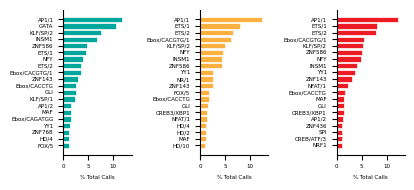

In [29]:
plot_multicell_tf_panels(
    dfs={
        'K562' : k_mpac_collapsed_dels,
        'HepG2' : h_mpac_collapsed_dels,
        'SKNSH' : s_mpac_collapsed_dels
    },
    cell_colors={
        'K562' : '#00A79D',
        'HepG2' : '#FBB040',
        'SKNSH' : '#ED1C24'
    },
    top_n=20,
    activity_type='Activator',
    plot_type='percentages',
    output_path='../../../../../analyses/figures/top20_activator_tfs_per_cell_type_v3.pdf'
)

Plot saved to: ../../../../../analyses/figures/top10_repressor_tfs_per_cell_type_v3.pdf


(<Figure size 425x200 with 3 Axes>,
 array([<Axes: xlabel='% Total Calls'>, <Axes: xlabel='% Total Calls'>,
        <Axes: xlabel='% Total Calls'>], dtype=object),
 array([ 2.01727491,  2.19354547,  2.25836818,  2.28069709,  2.32574839,
         3.29021984,  3.45891627,  3.48380268,  5.00934962, 37.77147584]))

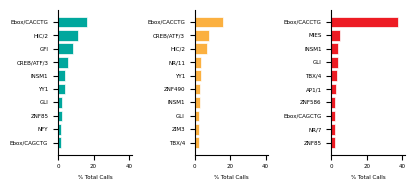

In [30]:
plot_multicell_tf_panels(
    dfs={
        'K562' : k_mpac_collapsed_dels,
        'HepG2' : h_mpac_collapsed_dels,
        'SKNSH' : s_mpac_collapsed_dels
    },
    cell_colors={
        'K562' : '#00A79D',
        'HepG2' : '#FBB040',
        'SKNSH' : '#ED1C24'
    },
    top_n=10,
    activity_type='Repressor',
    plot_type='percentages',
    output_path='../../../../../analyses/figures/top10_repressor_tfs_per_cell_type_v3.pdf'
)

In [ ]:
### SCRATCH BELOW ###

In [31]:
# open clinvar and cosmic predictions for doing a seqlet enrichment comparison
clinvar_preds = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/clinvar/processed_data/clinvar_20260314_pathogenic_and_benign_preds.tsv', sep = '\t')
cosmic_preds = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/cosmic/processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.031826.tsv', sep = '\t')

In [32]:
# filter each dataset for only dELS variants
clinvar_dels = clinvar_preds[clinvar_preds['encode_dELS'] == 1]
cosmic_dels = cosmic_preds[cosmic_preds['encode_dELS'] == 1]
# filter all clinvar dels for pathogenic variants
clinvar_dels_path = clinvar_dels[clinvar_dels['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])]
clinvar_dels_benign = clinvar_dels[clinvar_dels['clinsig'].isin(['Benign', 'Likely_benign'])]
# get numbers for 2x2 table
n_path_seqlet = clinvar_dels_path['dELS_seqlet'].sum()
n_benign_seqlet = clinvar_dels_benign['dELS_seqlet'].sum()
n_path_noSeqlet = len(clinvar_dels_path) - n_path_seqlet
n_benign_noSeqlet = len(clinvar_dels_benign) - n_benign_seqlet
# make a twobyto table for clinvar pathogenic variants
clinvar_dels_2x2 = Table2x2(np.array([[n_path_seqlet, n_benign_seqlet], [n_path_noSeqlet, n_benign_noSeqlet]]))
clinvar_dels_seqlet_or = clinvar_dels_2x2.oddsratio
clinvar_dels_seqlet_ci = clinvar_dels_2x2.oddsratio_confint(alpha=0.05)
clinvar_dels_seqlet_pval = stats.fisher_exact(np.array([[n_path_seqlet, n_benign_seqlet], [n_path_noSeqlet, n_benign_noSeqlet]]))[-1]

In [41]:
print(clinvar_dels_seqlet_or)
print(clinvar_dels_seqlet_ci)
print(clinvar_dels_seqlet_pval)

1.7594727089959792
(np.float64(1.0646161803136365), np.float64(2.9078500505127085))
0.03344451734417837


In [37]:
# filter cosmic dels into recurrent and benign
cosmic_dels_recurrent = cosmic_dels[cosmic_dels['recurrent'] == 1]
cosmic_dels_unique = cosmic_dels[cosmic_dels['recurrent'] == 0]
# get numbers for 2x2 table
n_recurrent_seqlet = cosmic_dels_recurrent['dELS_seqlet'].sum()
n_unique_seqlet = cosmic_dels_unique['dELS_seqlet'].sum()
n_recurrent_noSeqlet = len(cosmic_dels_recurrent) - n_recurrent_seqlet
n_unique_noSeqlet = len(cosmic_dels_unique) - n_unique_seqlet
# make a twobytwo table for cosmic recurrent variants
cosmic_dels_2x2 = Table2x2(np.array([[n_recurrent_seqlet, n_unique_seqlet], [n_recurrent_noSeqlet, n_unique_noSeqlet]]))
cosmic_dels_seqlet_or = cosmic_dels_2x2.oddsratio
cosmic_dels_seqlet_ci = cosmic_dels_2x2.oddsratio_confint(0.05)
cosmic_dels_seqlet_pval = stats.fisher_exact(np.array([[n_recurrent_seqlet, n_unique_seqlet], [n_recurrent_noSeqlet, n_unique_noSeqlet]]))[-1]

In [42]:
print(cosmic_dels_seqlet_or)
print(cosmic_dels_seqlet_ci)
print(cosmic_dels_seqlet_pval)

1.1211314951501996
(np.float64(1.0385133925109271), np.float64(1.2103222148909325))
0.003902786780255612


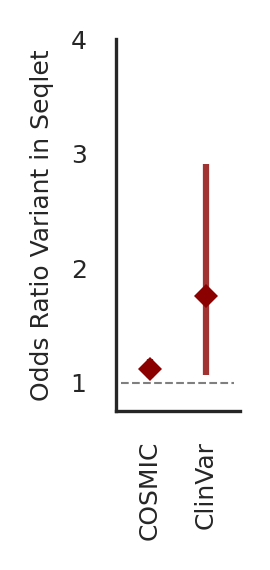

In [39]:
# plot the enrichmets for recurrent/pathogenic variants in seqlets
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.figure(figsize = (1,2), dpi = 300)
# make point plot of oddsratios
with sns.axes_style("white"):
    sns.pointplot(
    x=['COSMIC', 'ClinVar'], 
    y=[cosmic_dels_seqlet_or, clinvar_dels_seqlet_or],
    color="darkred", 
    linestyle="none", 
    marker="D", 
    markersize=4, 
    linewidth=0)
# add confidence intervals
# cosmic
mpl.vlines(x=0, ymin=cosmic_dels_seqlet_ci[0], ymax=cosmic_dels_seqlet_ci[1], color='darkred', alpha=0.8)
# clinvar
mpl.vlines(x=1, ymin=clinvar_dels_seqlet_ci[0], ymax=clinvar_dels_seqlet_ci[1], color='darkred', alpha=0.8)
mpl.ylim(0.75, 4)
mpl.hlines(y=1, xmin=-0.5, xmax=1.5, linestyle='dashed', color='k', alpha=0.5, linewidth=0.5)
mpl.xticks(rotation=90, fontsize=6)
mpl.yticks(fontsize=6)
mpl.ylabel('Odds Ratio Variant in Seqlet', fontsize=6)
sns.despine()
mpl.tight_layout()
#mpl.savefig('../../../../../analyses/figures/oddsR_cosmic_recurrent_clinvar_pathogenic_in_seqlet.pdf')

In [ ]:
# define function to get enhancers with multiple instances of a given TF
def get_multiTF_enhancers (collapsed_bed):
    grouped = collapsed_bed.groupby(['enhancer_id', 'representative_tf']).transform('size')
    # filter full df for only the multi-tf enhancers
    multiTFs = collapsed_bed[grouped > 1]
    # filter all seqlets for those enhancers
    multiTF_bedLike= collapsed_bed[collapsed_bed['enhancer_id'].isin(list(multiTFs['enhancer_id'].unique()))].sort_values(['enhancer_id', 1])
    # sort to get things ordered 
    #sorted = multiTF_enhs.sort_values(['enhancer_id', 1])
    return multiTF_bedLike

In [ ]:
k_noMin_collapsed[k_noMin_collapsed['enhancer_id'] == 'EH38E2776536']

In [ ]:
# get enhancers with multiple instances of a given tf
# k562
k_multiTF_enhancers = get_multiTF_enhancers(k_noMin_collapsed)
# hepg2
h_multiTF_enhancers = get_multiTF_enhancers(h_noMin_collapsed)
# sknsh
s_multiTF_enhancers = get_multiTF_enhancers(s_noMin_collapsed)

In [ ]:
# save bed files for intersecting with common variants bed file
# k562
k_multiTF_enhancers.filter([0,1,2,3]).to_csv('../../../../../processed_data/multiTF_beds/k562_mulitTF_beds4gnomad.bed', 
                                             sep = '\t',
                                             index = False,
                                             header = None)
# hepg2
h_multiTF_enhancers.filter([0,1,2,3]).to_csv('../../../../../processed_data/multiTF_beds/hepg2_mulitTF_beds4gnomad.bed', 
                                             sep = '\t',
                                             index = False,
                                             header = None)
# sknsh
s_multiTF_enhancers.filter([0,1,2,3]).to_csv('../../../../../processed_data/multiTF_beds/sknsh_mulitTF_beds4gnomad.bed', 
                                             sep = '\t',
                                             index = False,
                                             header = None)